45 [ 0.76227117 -0.58540313]
47 [-0.01133307 -0.02441928]
48 [ 0.3282496  -0.59303852]
49 [-0.63261424 -0.86933592]
5 [ 0.60777288 -0.95029684]
6 [-0.65012994 -0.55446758]
8 [-0.79818306  0.79200896]
13 [0.52898652 0.79128612]
14 [-0.2970769   0.95163243]
16 [-0.35243622 -0.37275667]
18 [-0.85923572 -0.59852666]
30 [-0.69609457 -0.02191303]
35 [ 0.18128273 -0.417214  ]
43 [-0.00244946 -0.8619615 ]
44 [ 0.33632629 -0.8851515 ]
0 [0.95178965 0.36172373]
1 [0.54167833 0.53372456]
2 [ 0.32262116 -0.83723693]
3 [-0.79526936 -0.0614753 ]
4 [-0.6729568  0.5851279]
41 [-0.33184617  0.40654795]
42 [-0.31753013  0.83037287]


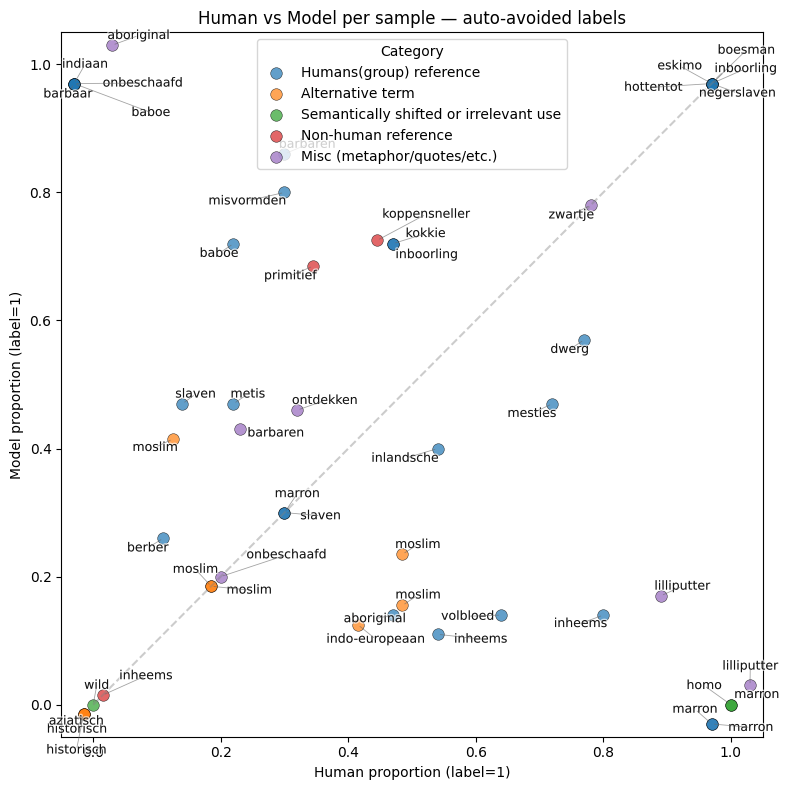

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from adjustText import adjust_text

# df: [sample_id, human_prop, model_prop, category_name, term]

raw_samples = [
    # LLMs and human unanimously 1
    ("s001", 1, 1.0, 1.0, 'boesman'),
    ("s002", 1, 1.0, 1.0, 'inboorling'),
    ("s003", 1, 1.0, 1.0, 'negerslaven'),
    ("s004", 1, 1.0, 1.0, 'hottentot'),
    ("s005", 1, 1.0, 1.0, 'eskimo'),

    # LLMs and human unanimously 0
    ("s101", 3, 0.0, 0.0, 'historisch'),
    ("s102", 3, 0.0, 0.0, 'historisch'),
    ("s103", 4, 0.0, 0.0, 'wild'),
    ("s104", 3, 0.0, 0.0, 'aziatisch'),
    ("s105", 2, 0.0, 0.0, 'inheems'),

    # LLM and human are almost equal
    ("s201", 5, 0.29, 0.43, 'ontdekken'),
    ("s202", 5, 0.17, 0.17, 'onbeschaafd'),
    ("s203", 5, 0.2, 0.4, 'barbaren'),
    ("s204", 3, 0.2, 0.2, 'moslim'),
    ("s205", 3, 0.2, 0.2, 'moslim'),
    ("s206", 1, 0.57, 0.43, 'inlandsche'),
    ("s207", 1, 0.33, 0.33, 'slaven'),
    ("s208", 1, 0.14, 0.29, 'berber'),
    ("s209", 1, 0.33, 0.33, 'marron'),
    ("s210", 5, 0.75, 0.75, 'zwartje'),

    # LLM < human
    ("s301", 1, 0.8, 0.6, 'dwerg'),
    ("s302", 1, 0.75, 0.5, 'mesties'),
    ("s303", 5, 0.86, 0.14, 'lilliputter'),
    ("s304", 1, 0.67, 0.17, 'volbloed'),
    ("s305", 1, 0.83, 0.17, 'inheems'),
    ("s306", 1, 0.5, 0.17, 'aboriginal'),
    ("s307", 1, 0.57, 0.14, 'inheems'),
    ("s308", 3, 0.43, 0.14, 'indo-europeaan'),
    ("s309", 3, 0.5, 0.25, 'moslim'),
    ("s310", 3, 0.5, 0.17, 'moslim'),

    # LLM > human
    ("s401", 1, 0.5, 0.75, 'kokkie'),
    ("s402", 1, 0.33, 0.89, 'barbaren'),
    ("s403", 2, 0.33, 0.67, 'primitief'),
    ("s404", 1, 0.17, 0.5, 'slaven'),
    ("s405", 1, 0.33, 0.83, 'misvormden'),
    ("s406", 1, 0.5, 0.75, 'inboorling'),
    ("s407", 1, 0.25, 0.5, 'metis'),
    ("s408", 1, 0.25, 0.75, 'baboe'),
    ("s409", 2, 0.43, 0.71, 'koppensneller'),
    ("s410", 3, 0.14, 0.43, 'moslim'),

    # human=1 and LLM=0
    ("s501", 5, 1.0, 0, 'lilliputter'),
    ("s502", 4, 1.0, 0, 'marron'),
    ("s503", 4, 1.0, 0, 'homo'),
    ("s504", 1, 1.0, 0, 'marron'),
    ("s505", 1, 1.0, 0, 'marron'),

    # human=0 and LLM=1
    ("s601", 1, 0.0, 1, 'barbaar'),
    ("s602", 5, 0.0, 1, 'aboriginal'),
    ("s603", 1, 0.0, 1, 'baboe'),
    ("s604", 1, 0.0, 1, 'indiaan'),
    ("s605", 1, 0.0, 1, 'onbeschaafd'),
]

df = pd.DataFrame(raw_samples, columns=["sample_id", "category", "human_prop", "model_prop", "term"])

# Category names to put in the figure
category_names = {
    1: "Humans(group) reference",
    2: "Non-human reference",
    3: "Alternative term",
    4: "Semantically shifted or irrelevant use",
    5: "Misc (metaphor/quotes/etc.)"
}
df["category_name"] = df["category"].map(category_names)

cats = df["category_name"].unique()
cat_offsets = {cat: off for cat, off in zip(cats, np.linspace(-0.03, 0.03, len(cats)))}

df = df.copy()
df["x"] = df.apply(lambda r: r["human_prop"] + cat_offsets[r["category_name"]], axis=1)
df["y"] = df.apply(lambda r: r["model_prop"] + cat_offsets[r["category_name"]], axis=1)

fig, ax = plt.subplots(figsize=(8, 8))
for cat in cats:
    sub = df[df["category_name"] == cat]
    ax.scatter(
        sub["x"], sub["y"],
        s=70, alpha=0.7, edgecolor="black", linewidth=0.4,
        label=cat
    )

to_annotate = df

texts = []
for _, r in to_annotate.iterrows():
    t = ax.text(
        r["x"], r["y"], str(r["term"]),
        fontsize=9, color="black", alpha=0.9, ha="center", va="center",
        path_effects=[pe.withStroke(linewidth=2, foreground="white", alpha=0.65)]
    )
    texts.append(t)


adjust_text(
    texts, ax=ax,
    only_move={'points':'y', 'text':'xy'}, 
    expand_points=(1.2, 1.4), 
    expand_text=(1.1, 1.2),  
    arrowprops=dict(arrowstyle="-", color="0.4", lw=0.6, alpha=0.6)
)

ax.plot([0, 1], [0, 1], "--", color="gray", alpha=0.4)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Human proportion (label=1)")
ax.set_ylabel("Model proportion (label=1)")
ax.set_title("Human vs Model per sample — auto-avoided labels")
ax.legend(title="Category", loc="best")
fig.tight_layout()

fig.savefig("./selected samples in the strata.pdf", format="pdf", bbox_inches="tight")
plt.show()